In [2]:
import os
os.chdir("..")

import duckdb

con = duckdb.connect("data/clickstream.duckdb")

In [3]:
con.sql("""
SELECT
    (SELECT COUNT(*) FROM user_cohort) AS cohort_users,
    (SELECT COUNT(*) FROM user_week_activity) AS user_week_rows,
    (SELECT MIN(cohort_week) FROM user_cohort) AS first_cohort_week,
    (SELECT MAX(cohort_week) FROM user_cohort) AS last_cohort_week,
    (SELECT MIN(activity_week) FROM user_week_activity) AS first_activity_week,
    (SELECT MAX(activity_week) FROM user_week_activity) AS last_activity_week
""").df()

,cohort_users,user_week_rows,first_cohort_week,last_cohort_week,first_activity_week,last_activity_week
0,1063104,2101303,2019-09-30,2019-11-25,2019-09-30,2019-11-25


In [15]:
con.close()

In [16]:
import duckdb

con = duckdb.connect(
    r"D:\clickstream-funnel-cohort-engine\data\clickstream.duckdb"
)

In [17]:
con.sql("""
SHOW TABLES
""").df()

,name
0,dim_price_band
1,events_sessionized
2,mart_cohort_weekly
3,mart_funnel_brand
4,mart_funnel_category
5,mart_funnel_dow
6,mart_funnel_hour
7,mart_funnel_overall
8,mart_funnel_priceband
9,mart_session_diagnostics


In [18]:
con.sql("""
SELECT *
FROM mart_cohort_weekly
ORDER BY cohort_week, week_number
LIMIT 20
""").df()

,cohort_week,week_number,cohort_users,active_users,purchasing_users,retention_pct,purchase_retention_pct,is_baseline_cohort,is_partial_week
0,2019-09-30,0,169957,169957,15866.0,100.00,9.34,True,True
1,2019-09-30,1,169957,60758,8653.0,35.75,5.09,True,False
2,2019-09-30,2,169957,54614,7412.0,32.13,4.36,True,False
3,2019-09-30,3,169957,46964,6254.0,27.63,3.68,True,False
4,2019-09-30,4,169957,44873,4901.0,26.40,2.88,True,False
5,2019-09-30,5,169957,49808,5058.0,29.31,2.98,True,False
6,2019-09-30,6,169957,54417,9219.0,32.02,5.42,True,False
7,2019-09-30,7,169957,40753,4005.0,23.98,2.36,True,False
8,2019-09-30,8,169957,36365,3790.0,21.40,2.23,True,True
9,2019-10-07,0,150883,150883,11692.0,100.00,7.75,False,False


In [19]:
con.sql("""
SELECT
    MIN(week_number) AS min_week_number,
    MAX(week_number) AS max_week_number,
    COUNT(DISTINCT cohort_week) AS n_cohorts,
    COUNT(*) AS n_rows
FROM mart_cohort_weekly
""").df()

,min_week_number,max_week_number,n_cohorts,n_rows
0,0,8,9,45


In [20]:
con.sql("""
SELECT
    cohort_week,
    cohort_users,
    MAX(week_number) AS max_week_number,
    BOOL_OR(is_baseline_cohort) AS is_baseline_cohort,
    BOOL_OR(is_partial_week) AS has_partial_week
FROM mart_cohort_weekly
GROUP BY cohort_week, cohort_users
ORDER BY cohort_week
""").df()

,cohort_week,cohort_users,max_week_number,is_baseline_cohort,has_partial_week
0,2019-09-30,169957,8,True,True
1,2019-10-07,150883,7,False,True
2,2019-10-14,123295,6,False,True
3,2019-10-21,109821,5,False,True
4,2019-10-28,92249,4,False,True
5,2019-11-04,113926,3,False,True
6,2019-11-11,116995,2,False,True
7,2019-11-18,110611,1,False,True
8,2019-11-25,75367,0,False,True


In [21]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect(
    r"D:\clickstream-funnel-cohort-engine\data\clickstream.duckdb"
)

df = con.sql("""
    SELECT *
    FROM mart_cohort_weekly
""").df()

df["cohort_week"] = pd.to_datetime(df["cohort_week"])

df.head(12)

,cohort_week,week_number,cohort_users,active_users,purchasing_users,retention_pct,purchase_retention_pct,is_baseline_cohort,is_partial_week
0,2019-09-30,0,169957,169957,15866.0,100.00,9.34,True,True
1,2019-09-30,1,169957,60758,8653.0,35.75,5.09,True,False
2,2019-09-30,2,169957,54614,7412.0,32.13,4.36,True,False
3,2019-09-30,3,169957,46964,6254.0,27.63,3.68,True,False
4,2019-09-30,4,169957,44873,4901.0,26.40,2.88,True,False
5,2019-09-30,5,169957,49808,5058.0,29.31,2.98,True,False
6,2019-09-30,6,169957,54417,9219.0,32.02,5.42,True,False
7,2019-09-30,7,169957,40753,4005.0,23.98,2.36,True,False
8,2019-09-30,8,169957,36365,3790.0,21.40,2.23,True,True
9,2019-10-07,0,150883,150883,11692.0,100.00,7.75,False,False


In [23]:
total_users = con.sql("""
    SELECT COUNT(*)
    FROM user_cohort
""").fetchone()[0]

assert (
    df.loc[df.week_number == 0, "retention_pct"] == 100
).all()

assert (
    df.loc[df.week_number == 0, "cohort_users"].sum()
    == total_users
)

assert (
    df.week_number >= 0
).all()

print(
    "OK. Users:",
    f"{total_users:,}",
    "| cohorts:",
    df.cohort_week.nunique()
)

OK. Users: 1,063,104 | cohorts: 9


In [24]:
df[
    df.week_number == 0
][
    [
        "cohort_week",
        "cohort_users",
        "is_baseline_cohort",
        "is_partial_week"
    ]
]

,cohort_week,cohort_users,is_baseline_cohort,is_partial_week
0,2019-09-30,169957,True,True
9,2019-10-07,150883,False,False
17,2019-10-14,123295,False,False
24,2019-10-21,109821,False,False
30,2019-10-28,92249,False,False
35,2019-11-04,113926,False,False
39,2019-11-11,116995,False,False
42,2019-11-18,110611,False,False
44,2019-11-25,75367,False,True


In [1]:
import os

def cohort_heatmap(df, value_col, title, fname):
    # Remove incomplete follow-up weeks.
    # Keep week 0 even when the cohort starts in a partial week.
    d = df[
        ~((df["week_number"] > 0) & df["is_partial_week"])
    ]

    # Cohort rows × weeks since first seen
    pv = d.pivot(
        index="cohort_week",
        columns="week_number",
        values=value_col
    )

    # Remove cohorts that have no follow-up data
    pv = pv.dropna(thresh=2)

    # Cohort sizes for row labels
    sizes = (
        d.groupby("cohort_week")["cohort_users"]
        .first()
    )

    labels = [
        f"{k:%d %b}  (n={sizes[k]:,})"
        for k in pv.index
    ]

    # Mark the baseline cohort
    labels[0] += " baseline"

    # Don't let 100% week 0 determine the color scale
    vmax = pv.drop(columns=0).max().max()

    fig, ax = plt.subplots(figsize=(11, 5))

    sns.heatmap(
        pv,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        vmin=0,
        vmax=vmax,
        yticklabels=labels,
        ax=ax,
        cbar_kws={"label": "% of cohort"}
    )

    ax.set_title(title)
    ax.set_xlabel("Weeks since first seen")
    ax.set_ylabel("Cohort (week of first seen)")

    os.makedirs("reports/figures", exist_ok=True)

    fig.savefig(
        f"reports/figures/{fname}",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    return pv

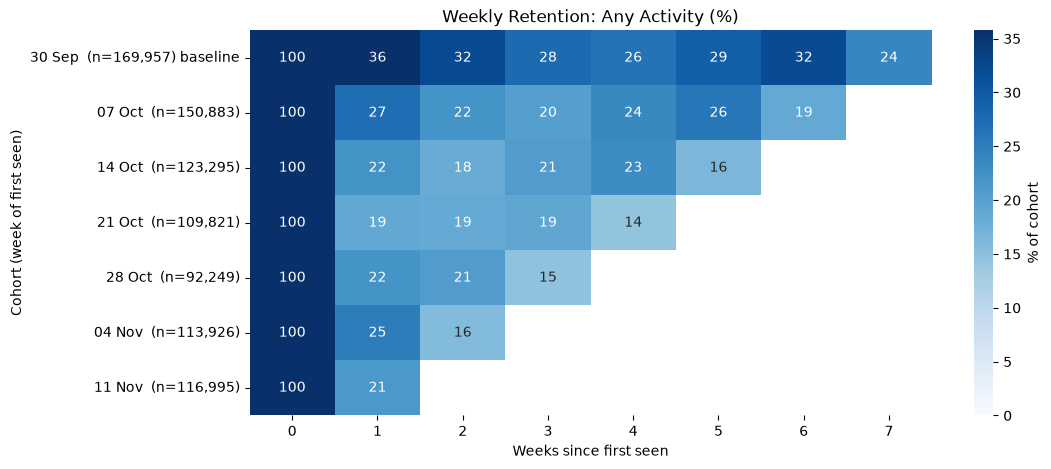

week_number,0,1,2,3,4,5,6,7
cohort_week,,,,,,,,
2019-09-30,100.0,35.75,32.13,27.63,26.40,29.31,32.02,23.98
2019-10-07,100.0,27.10,22.03,20.38,23.53,25.87,18.59,NaN
2019-10-14,100.0,22.11,18.23,20.69,23.00,16.38,NaN,NaN
2019-10-21,100.0,18.72,18.51,19.25,14.50,NaN,NaN,NaN
2019-10-28,100.0,22.01,20.70,14.72,NaN,NaN,NaN,NaN
2019-11-04,100.0,25.19,15.86,NaN,NaN,NaN,NaN,NaN
2019-11-11,100.0,21.28,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
pv_any = cohort_heatmap(
    df,
    "retention_pct",
    "Weekly Retention: Any Activity (%)",
    "cohort_retention_any.png"
)

pv_any

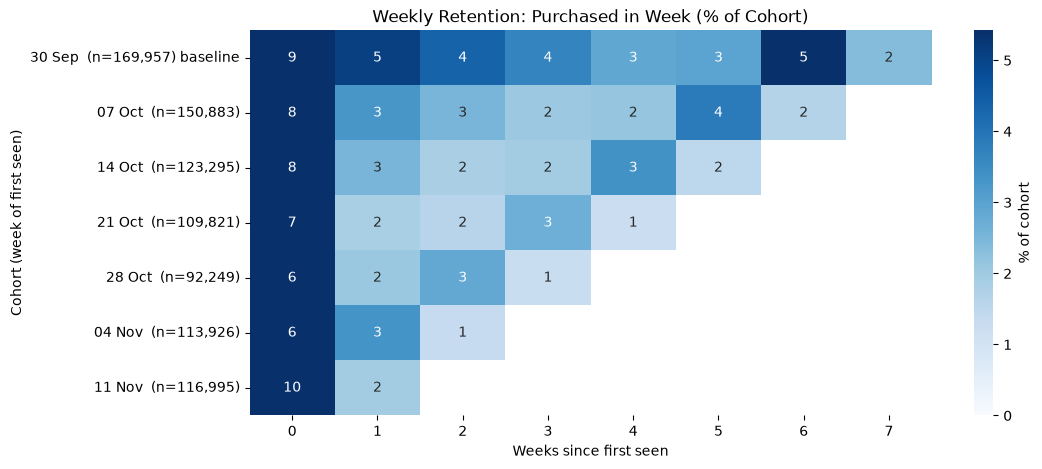

week_number,0,1,2,3,4,5,6,7
cohort_week,,,,,,,,
2019-09-30,9.34,5.09,4.36,3.68,2.88,2.98,5.42,2.36
2019-10-07,7.75,3.29,2.54,2.07,2.15,3.87,1.66,NaN
2019-10-14,7.68,2.52,1.84,1.96,3.37,1.52,NaN,NaN
2019-10-21,6.58,1.85,1.61,2.68,1.21,NaN,NaN,NaN
2019-10-28,6.34,2.09,2.85,1.28,NaN,NaN,NaN,NaN
2019-11-04,5.90,3.34,1.36,NaN,NaN,NaN,NaN,NaN
2019-11-11,10.08,1.95,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
pv_buy = cohort_heatmap(
    df,
    "purchase_retention_pct",
    "Weekly Retention: Purchased in Week (% of Cohort)",
    "cohort_retention_purchase.png"
)

pv_buy

## Cohort Retention — Key Findings

### 1. Retention drops sharply after the first week
The baseline cohort's any-activity retention falls from 100% in Week 0 to approximately 36% in Week 1. This indicates that a substantial share of users did not return in the following week.

### 2. Purchase retention is much lower than activity retention
For the baseline cohort, approximately 36% of users return with any activity in Week 1, while only about 5% make a purchase that week. Returning to the store does not necessarily translate into a purchase.

### 3. Retention generally declines over time
The baseline cohort's any-activity retention reaches approximately 21% by Week 8. Purchase retention is approximately 2% in Week 8. These figures describe observed behavior during the available dataset period.

### 4. Interpret cohort comparisons carefully
The first cohort is a baseline cohort based on the first week in the dataset; it does not necessarily represent genuinely new customers. The dataset covers only nine weekly cohort periods, and the first and last calendar weeks are partial.

### Business Recommendations
- Investigate why users do not return after their first observed week.
- Examine product discovery, pricing, checkout friction, and follow-up campaigns as possible retention opportunities.
- Analyze repeat-purchase behavior separately from general activity.
- Validate these patterns using a longer observation period before making long-term retention decisions.

In [9]:
con.close()

In [10]:
import duckdb

con = duckdb.connect(
    r"D:\clickstream-funnel-cohort-engine\data\clickstream.duckdb"
)

category_retention = con.sql("""
    SELECT *
    FROM mart_retention_by_first_category
    ORDER BY week1_retention_pct DESC
""").df()

category_retention

,first_category,users,retained_week1,week1_retention_pct
0,accessories,4024,1258,31.26
1,auto,19240,5902,30.68
2,furniture,28950,8505,29.38
3,appliances,93223,25920,27.80
4,construction,13405,3577,26.68
5,sport,4143,1087,26.24
6,computers,39751,10262,25.82
7,apparel,44743,11512,25.73
8,electronics,388716,94546,24.32
9,kids,17237,3510,20.36


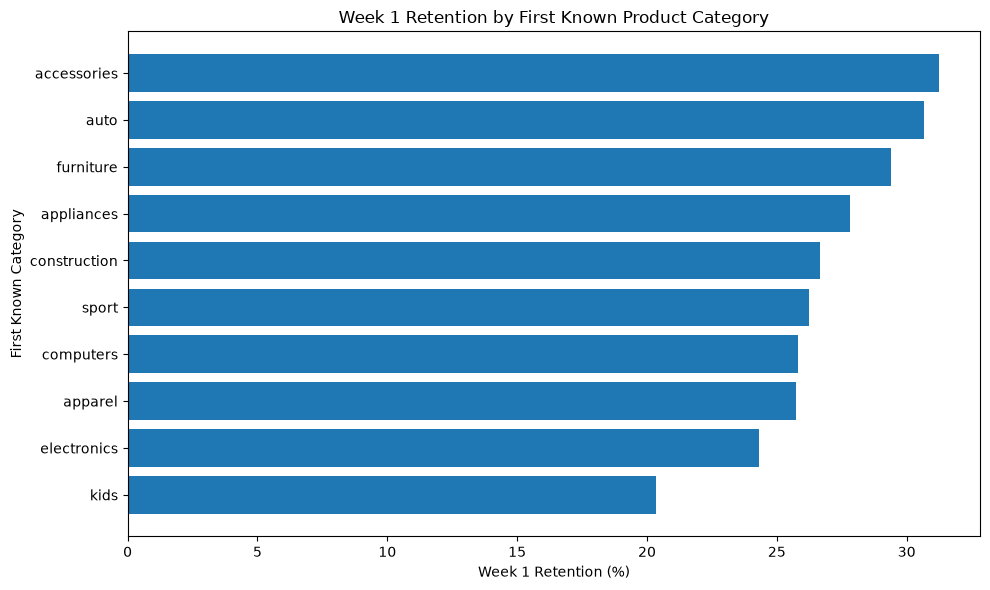

In [11]:
import matplotlib.pyplot as plt

plot_df = category_retention.sort_values(
    "week1_retention_pct",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["first_category"],
    plot_df["week1_retention_pct"]
)

plt.xlabel("Week 1 Retention (%)")
plt.ylabel("First Known Category")
plt.title("Week 1 Retention by First Known Product Category")
plt.tight_layout()

plt.savefig(
    "reports/figures/retention_by_first_category.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Week 1 Retention by First Known Category — Findings

### Key Findings

1. **Accessories has the highest observed retention:** 31.26%, among 4,024 eligible users.
2. **Auto also shows strong retention:** 30.68%, among 19,240 users.
3. **Appliances is a substantial retention opportunity:** 27.80% retention across 93,223 users.
4. **Electronics has the largest user base:** 388,716 users, with 24.32% Week 1 retention.
5. **Kids has the lowest observed retention:** 20.36%, among the displayed categories.

### Business Recommendations

- Investigate what encourages users in accessories and auto to return.
- Examine the electronics user journey because it represents the largest analyzed category.
- Investigate potential retention barriers for kids-category users.
- Validate differences while accounting for product mix, acquisition source, and other user characteristics.

### Methodology and Limitations

- Category represents the user's first known, non-unknown product category.
- Only eligible cohorts with observable Week 1 activity are included.
- Categories with fewer than 1,000 users are excluded.
- These are observational associations and do not establish causation.